In [89]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_pearson_correlation(csv_file):
    try:
        # 读取CSV文件
        df = pd.read_csv(csv_file)
        print(f"成功读取文件：{csv_file}")
        
        # 检查并处理class列
        if "Label" in df.columns:
            # 提取特征列表（排除class）
            features = [col for col in df.columns if col != "Label"]
            # 筛选数值列
            numeric_df = df.select_dtypes(include=[np.number])
            
            # 计算特征间的Pearson相关系数矩阵
            corr_matrix_features = numeric_df[features].corr(method='pearson')
            
            # 计算每个特征与class的Pearson相关系数
            corr_with_class = {}
            for feat in features:
                if feat in numeric_df.columns:  # 确保特征是数值型
                    corr, _ = stats.pearsonr(numeric_df[feat], numeric_df["Label"])
                    corr_with_class[feat] = corr
            
            # 将特征与class的相关性转换为DataFrame
            corr_df_class = pd.DataFrame.from_dict(
                corr_with_class, 
                orient='index', 
                columns=['correlation_with_class']
            )
            
            return corr_matrix_features, corr_df_class
        else:
            print(f"Dataset: 'class' column not found.")
            return None, None
        
    except Exception as e:
        print(f"计算过程中发生错误：{str(e)}")
        return None, None
        
if __name__ == "__main__":
    for name in ['0.4', '0.5', '0.6', '0.7']:
        # 输入文件路径
        csv_path = f"../Results/merged_encode_cksaap_{name}_out.csv"
        
        # 计算相关系数矩阵和特征与class的相关性
        corr_matrix_features, corr_df_class = calculate_pearson_correlation(csv_path)
        
        # 保存结果
        if corr_matrix_features is not None:
            # 保存特征间的相关系数矩阵
            features_out_path = f"pearson_correlation_matrix_features_{name}.csv"
            corr_matrix_features.to_csv(features_out_path)
            print(f"特征间相关系数矩阵已保存到：{features_out_path}")
            
        if corr_df_class is not None:
            # 保存特征与class的相关系数
            class_out_path = f"pearson_correlation_with_class_{name}.csv"
            corr_df_class.to_csv(class_out_path)
            print(f"特征与class的相关系数已保存到：{class_out_path}")
            
        print("-" * 50)
    

成功读取文件：../Results/merged_encode_cksaap_0.4_out.csv
特征间相关系数矩阵已保存到：pearson_correlation_matrix_features_0.4.csv
特征与class的相关系数已保存到：pearson_correlation_with_class_0.4.csv
--------------------------------------------------
成功读取文件：../Results/merged_encode_cksaap_0.5_out.csv
特征间相关系数矩阵已保存到：pearson_correlation_matrix_features_0.5.csv
特征与class的相关系数已保存到：pearson_correlation_with_class_0.5.csv
--------------------------------------------------
成功读取文件：../Results/merged_encode_cksaap_0.6_out.csv
特征间相关系数矩阵已保存到：pearson_correlation_matrix_features_0.6.csv
特征与class的相关系数已保存到：pearson_correlation_with_class_0.6.csv
--------------------------------------------------
成功读取文件：../Results/merged_encode_cksaap_0.7_out.csv
特征间相关系数矩阵已保存到：pearson_correlation_matrix_features_0.7.csv
特征与class的相关系数已保存到：pearson_correlation_with_class_0.7.csv
--------------------------------------------------


In [90]:
import pandas as pd

# 遍历所有name值
for name in ['4', '5', '6', '7']:
    try:
        # 1. 构建文件路径
        corr_path = f"pearson_correlation_with_class_0.{name}.csv"
        rank_path = f"merged_encode_cksaap_0{name}.feature_rank.csv"
        
        # 2. 读取相关性文件（第一列是特征名，作为索引）
        # 假设相关性文件结构：第一列是特征名（索引），第二列是相关系数
        corr_df = pd.read_csv(corr_path, index_col=0)
        # 重置索引，将特征名转为普通列（便于匹配）
        corr_df = corr_df.reset_index().rename(columns={'index': 'feature'})
        
        # 3. 读取特征排名文件（第一列是特征名，第二列是排名数值）
        # 假设排名文件无表头，第一列是特征名，第二列是排名值
        rank_df = pd.read_csv(
            rank_path, 
            header=None,  # 无表头
            names=['feature', 'rank_value']  # 手动命名列
        )
        
        # 4. 按特征名匹配，添加排名列（使用merge实现左连接，保留相关性文件所有特征）
        merged_df = pd.merge(
            corr_df, 
            rank_df, 
            on='feature',  # 按feature列匹配
            how='left'  # 保留相关性文件的所有行，无匹配则为NaN
        )
        
        # 5. 恢复索引为特征名，保存结果
        merged_df = merged_df.set_index('feature')
        merged_df.to_csv(corr_path)  # 覆盖原文件，或改为新路径如f"updated_{corr_path}"
        
        print(f"已成功为 {name} 添加排名列，保存至 {corr_path}")
    
    except Exception as e:
        print(f"处理 {name} 时出错：{str(e)}")

已成功为 4 添加排名列，保存至 pearson_correlation_with_class_0.4.csv
已成功为 5 添加排名列，保存至 pearson_correlation_with_class_0.5.csv
已成功为 6 添加排名列，保存至 pearson_correlation_with_class_0.6.csv
已成功为 7 添加排名列，保存至 pearson_correlation_with_class_0.7.csv


Dataset 0.6: 56 features


/tmp/ipykernel_723044/2569035066.py:76: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='ward', metric='euclidean')


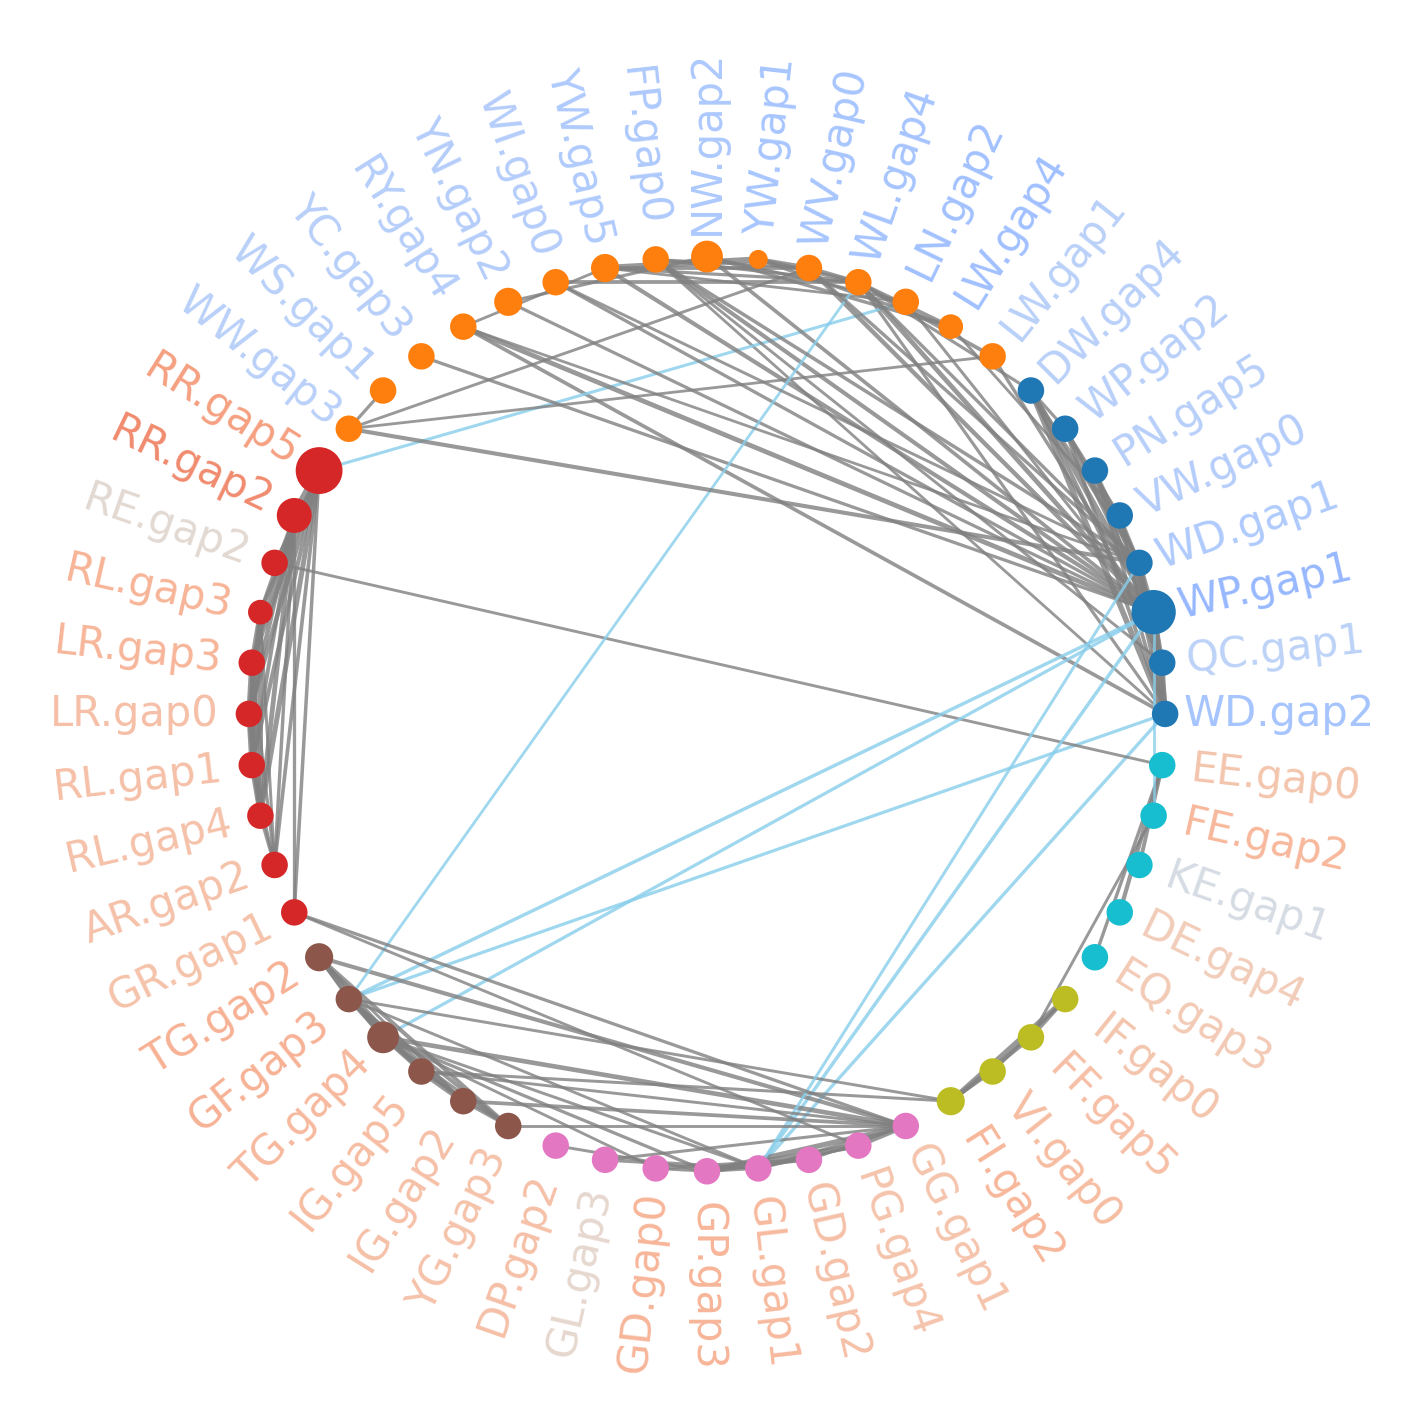

In [350]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.colors import Normalize

# 配置参数
# 0.4
# CORR_THRESHOLD = 0.15  # 特征间相关性筛选阈值
# COMMUNITY_THRESHOLD = 2 # 聚类社区划分阈值
# 0.5
# CORR_THRESHOLD = 0.2   # 特征间相关性筛选阈值
# COMMUNITY_THRESHOLD = 2 # 聚类社区划分阈值
# # # 0.6
CORR_THRESHOLD = 0.2  # 特征间相关性筛选阈值
COMMUNITY_THRESHOLD = 2 # 聚类社区划分阈值
# # 0.7
# CORR_THRESHOLD = 0.15  # 特征间相关性筛选阈值
# COMMUNITY_THRESHOLD = 2 # 聚类社区划分阈值

cm_to_inch = 0.393701  # cm转英寸系数
fig_size_cm = 7.5  # 图形大小（cm）
fig_size_inch = fig_size_cm * cm_to_inch  # 转换为英寸
rank_cmap = plt.cm.coolwarm  # 用于rank_value的颜色映射（值越小颜色越亮）


for name in ['0.6']:
# for name in ['0.6', '0.7', '0.8', '0.9']:
    try:
        # 1. 读取必要数据
        # 1.1 特征间相关性矩阵
        corr_matrix = pd.read_csv(f"pearson_correlation_matrix_features_{name}.csv", index_col=0)
        # 1.2 特征与class的相关性（含rank_value）
        corr_with_class = pd.read_csv(f"pearson_correlation_with_class_{name}.csv", index_col=0)
        # 重置索引为特征名列
        corr_with_class = corr_with_class.reset_index().rename(columns={'index': 'feature'})
        # 提取特征与class的相关系数和排名
        feat_corr_class = dict(zip(corr_with_class['feature'], corr_with_class['correlation_with_class']))
        feat_rank = dict(zip(corr_with_class['feature'], corr_with_class['rank_value']))

        # 2. 筛选特征（保留与至少一个特征强相关的特征）
        keep_cols = []
        for col in corr_matrix.columns:
            if col not in feat_corr_class:  # 确保特征在correlation_with_class中存在
                continue
            other_corr = corr_matrix.drop(col, axis=0)[col]
            max_abs_corr = other_corr.abs().max() if not other_corr.empty else 0
            if max_abs_corr >= CORR_THRESHOLD:
                keep_cols.append(col)
        
        if not keep_cols:
            print(f"Dataset {name}: No features meet threshold. Skipping.")
            continue
        
        filtered_corr = corr_matrix.loc[keep_cols, keep_cols]
        features = filtered_corr.columns.tolist()
        print(f"Dataset {name}: {len(features)} features")

        # 3. 提取特征间强关联边
        edges = []
        for i, feat1 in enumerate(features):
            for j, feat2 in enumerate(features):
                if i < j:
                    corr = filtered_corr.loc[feat1, feat2]
                    if abs(corr) >= CORR_THRESHOLD:
                        edges.append((feat1, feat2, corr))
        
        if not edges:
            print(f"Dataset {name}: No significant correlations. Skipping.")
            continue

        # 4. 特征聚类划分社区
        distance_matrix = 1 - filtered_corr.values
        Z = linkage(distance_matrix, method='ward', metric='euclidean')
        partition = fcluster(Z, t=COMMUNITY_THRESHOLD, criterion='distance')
        nodes_by_community = {}
        for idx, feat in enumerate(features):
            comm_id = partition[idx]
            if comm_id not in nodes_by_community:
                nodes_by_community[comm_id] = []
            nodes_by_community[comm_id].append(feat)
        communities = sorted(nodes_by_community.keys())
        num_communities = len(communities)

        # 5. 分配社区角度范围
        total_angle = 2 * math.pi
        community_sizes = [len(nodes_by_community[comm]) for comm in communities]
        total_nodes = sum(community_sizes)
        community_angle_ranges = {}
        current_angle = 0
        for comm in communities:
            size = len(nodes_by_community[comm])
            angle_range = (size / total_nodes) * total_angle if total_nodes > 0 else 0
            community_angle_ranges[comm] = (current_angle, current_angle + angle_range)
            current_angle += angle_range

        # 6. 网络属性设置
        G = nx.Graph()
        G.add_nodes_from(features)
        G.add_weighted_edges_from([(u, v, abs(corr)) for u, v, corr in edges])

        # 6.1 节点大小：基于与class的相关系数绝对值（放大以突出差异）
        # 归一化相关系数到0-1范围（避免大小差异过大）
        corr_vals = [abs(feat_rank[feat]) for feat in features]
        corr_min, corr_max = min(corr_vals), max(corr_vals)
        norm_corr = [(c - corr_min) / (corr_max - corr_min) if corr_max != corr_min else 0.5 for c in corr_vals]
        node_sizes = [3 + 30 * nc for nc in norm_corr]  # 基础大小50，最大250

        # 6.2 节点颜色：按社区区分
        comm_colors = plt.cm.tab10(np.linspace(0, 1, num_communities))
        node_colors_clustered = [comm_colors[communities.index(partition[idx])] for idx in range(len(features))]

        # 6.3 标签颜色：基于rank_value（直接映射，无需归一化）
        rank_vals = [feat_corr_class[feat] for feat in features]

        rank_vals = [rv*1.4 for rv in rank_vals]

        node_font_colors = [rank_cmap((nr + 1) / 2) for nr in rank_vals]

        # 7. 绘制网络
        plt.figure(figsize=(fig_size_inch, fig_size_inch), dpi=500)
        # plt.figure()

        # 节点位置（环形布局）
        pos = {}
        radius = 1
        for comm in communities:
            angle_start, angle_end = community_angle_ranges[comm]
            nodes_in_comm = nodes_by_community[comm]
            num_nodes = len(nodes_in_comm)
            if num_nodes == 0:
                continue
            angle_step = (angle_end - angle_start) / num_nodes
            for idx, node in enumerate(nodes_in_comm):
                angle = angle_start + idx * angle_step
                pos[node] = (radius * math.cos(angle), radius * math.sin(angle))

        # 绘制节点和边
        nx.draw_networkx_nodes(
            G, pos,
            node_size=node_sizes,
            node_color=node_colors_clustered,
            alpha=1
        )
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v) for u, v, _ in edges],
            width=[2 * abs(corr) for u, v, corr in edges],
            edge_color=['grey' if corr > 0 else 'skyblue' for u, v, corr in edges],
            alpha=0.8
        )

        # 绘制标签（颜色反映rank_value）
        offset = 0.25
        for i, node in enumerate(G.nodes()):
            comm_id = partition[features.index(node)]
            nodes_in_comm = nodes_by_community[comm_id]
            idx_in_comm = nodes_in_comm.index(node)
            angle_start, angle_end = community_angle_ranges[comm_id]
            angle = angle_start + idx_in_comm * (angle_end - angle_start) / len(nodes_in_comm)
            r_label = radius + offset
            pos_label = (r_label * math.cos(angle), r_label * math.sin(angle))
            text_angle = (angle / math.pi * 180) % 360
            if 90 < text_angle < 270:
                text_angle += 180
            # 使用rank映射的颜色
            plt.text(
                pos_label[0], pos_label[1],
                node[:],  # 简化标签避免拥挤
                fontsize=6,
                ha='center', va='center',
                rotation=text_angle,
                color=node_font_colors[i]
            )

        plt.axis('off')
        plt.tight_layout()
        # 保存图像
        plt.savefig(f'rank_correlation_network_{name}.svg')
        plt.show()
    
    except Exception as e:
        print(f"Error processing {name}: {str(e)}")